# Model 1 — robust temperature-only baseline

Final baseline model:

$$
y_i=\log(PR_i)
$$

$$
y_i \sim StudentT(\nu,\mu_i,\sigma)
$$

$$
\mu_i=\alpha+\beta_T x_{T,i}
$$

where:

$$
x_T=\frac{T_m-T_{min}}{T_{max}-T_{min}}
$$

$T_{min}$ and $T_{max}$ are computed from the filtered modelling dataset, so $x_T$ is always in the range $[0,1]$. With this normalization, $\alpha$ is the expected $\log(PR)$ at the minimum observed module temperature, while $\beta_T$ is the change in $\log(PR)$ between the minimum and maximum observed module temperature.

The model uses a Student-t likelihood to make inference robust to remaining outliers. It captures the temperature relationship only and does not include wind or day-level effects.

In [2]:
import os
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
from cmdstanpy import CmdStanModel

RANDOM_SEED = 42
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

/Users/jwiater/Documents/private/da_project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load moderate dataset

In [3]:
DATA_PATH = "Bayesian-Data-Analytics-PV-Project/onemin-Ground-2016/2016/ground_model_data_irr50_5min.csv"
#DATA_PATH = "onemin-Ground-2016/2016/ground_model_data_irr50_all.csv"
#DATA_PATH = "onemin-Ground-2016/2016/ground_model_data_sunwindow_5min.csv"

STAN_MODEL_PATH = Path("Bayesian-Data-Analytics-PV-Project/model_1_temperature_studentt.stan")
STAN_PRIOR_PATH = Path("Bayesian-Data-Analytics-PV-Project/model_1_temperature_studentt_prior_predictive.stan")

if not os.path.exists(STAN_MODEL_PATH):
    DATA_PATH = "onemin-Ground-2016/2016/ground_model_data_irr50_5min.csv"
    STAN_MODEL_PATH = Path("model_1_temperature_studentt.stan")
    STAN_PRIOR_PATH = Path("model_1_temperature_studentt_prior_predictive.stan")

df = pd.read_csv(DATA_PATH)

print("Using data:", DATA_PATH)
print("Raw shape:", df.shape)
print(df.columns.tolist())

required = ["logPR", "PR", "T_module_C"]

#df = df[df["G_POA_Wm2"] >= 200]
df = df[df["hour"] >= 9]
df = df[df["hour"] <= 16]

df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=required).copy()


temp_min = df["T_module_C"].min()
temp_max = df["T_module_C"].max()
temp_range = temp_max - temp_min
df["x_T"] = (df["T_module_C"] - temp_min) / temp_range

if "day_id" in df.columns:
    df["day_id"] = pd.factorize(df["day_id"])[0] + 1

print("Model shape:", df.shape)
print(f"Temperature range: {temp_min:.2f} ... {temp_max:.2f} degC")
df[["logPR", "PR", "x_T", "T_module_C"]].head()

print(DATA_PATH)
print(len(df))
print(df["PR"].quantile([0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999]))
print(df["G_POA_Wm2"].min(), df["G_POA_Wm2"].max())

Using data: onemin-Ground-2016/2016/ground_model_data_irr50_5min.csv
Raw shape: (6952, 17)
['timestamp', 'day', 'day_id', 'month', 'hour', 'logPR', 'PR', 'x_T', 'z_wind', 'z_Tamb', 'T_module_C', 'T_amb_C', 'wind_ms', 'G_POA_Wm2', 'P_DC_kW', 'expected_P_DC_kW', 'power_ratio']
Model shape: (3998, 17)
Temperature range: 14.78 ... 66.68 degC
onemin-Ground-2016/2016/ground_model_data_irr50_5min.csv
3998
0.001    0.378142
0.010    0.572681
0.050    0.800463
0.500    0.942670
0.950    1.114670
0.990    1.279669
0.999    1.568228
Name: PR, dtype: float64
50.31 1188.0


## 2. Prepare Stan data

In [3]:
y = df["logPR"].to_numpy()
x_T = df["x_T"].to_numpy()
N = len(df)

T_range_C = float(df["T_module_C"].max() - df["T_module_C"].min())

stan_data = {
    "N": N,
    "y": y,
    "x_T": x_T,
    "T_range_C": T_range_C,
}

prior_data = {
    "N": N,
    "x_T": x_T,
    "T_range_C": T_range_C,
}

print("N =", N)
print("x_T range:", x_T.min(), x_T.max())
print("T_range_C =", T_range_C)
print("PR range:", df["PR"].min(), df["PR"].max())

N = 3998
x_T range: 0.0 1.0
T_range_C = 51.900000000000006
PR range: 0.363336966703 1.84742646173525


## 3. EDA

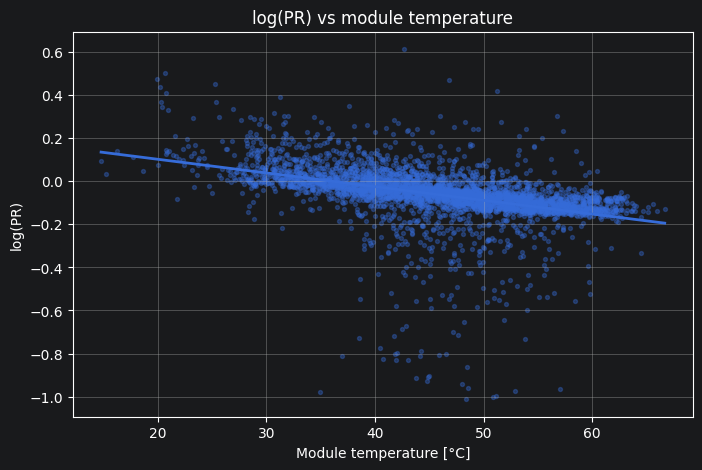

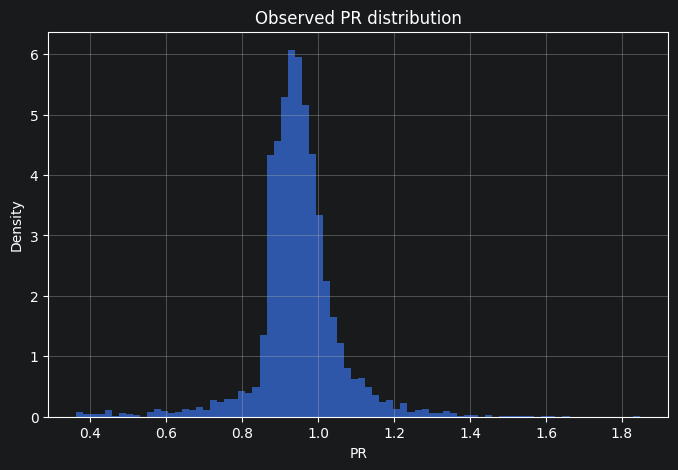

In [4]:
plt.figure()
plt.scatter(df["T_module_C"], df["logPR"], s=8, alpha=0.35)
p = np.polyfit(df["T_module_C"], df["logPR"], 1)
xx = np.linspace(df["T_module_C"].min(), df["T_module_C"].max(), 200)
plt.plot(xx, np.polyval(p, xx), linewidth=2)
plt.xlabel("Module temperature [°C]")
plt.ylabel("log(PR)")
plt.title("log(PR) vs module temperature")
plt.show()

plt.figure()
plt.hist(df["PR"], bins=80, density=True, alpha=0.75)
plt.xlabel("PR")
plt.ylabel("Density")
plt.title("Observed PR distribution")
plt.show()

## 4. Prior predictive check

Prior predictive checks assess whether the assumed priors generate plausible PR values before conditioning on the data. The summaries include $\beta_T$ on the normalized temperature scale and the corresponding $+10^\circ C$ effect for physical interpretation.

In [5]:

prior_model = CmdStanModel(stan_file=str(STAN_PRIOR_PATH), force_compile=True)

prior_fit = prior_model.sample(
    data=prior_data,
    fixed_param=True,
    chains=1,
    iter_sampling=2000,
    seed=RANDOM_SEED,
)

alpha_prior = prior_fit.stan_variable("alpha")
beta_T_10C_prior = prior_fit.stan_variable("beta_T_10C")
beta_T_norm_prior = prior_fit.stan_variable("beta_T_norm")
sigma_prior = prior_fit.stan_variable("sigma")
nu_prior = prior_fit.stan_variable("nu")
PR_prior = prior_fit.stan_variable("PR_prior")

print("Prior alpha:", np.percentile(alpha_prior, [5, 50, 95]))
print("Prior beta_T_10C:", np.percentile(beta_T_10C_prior, [5, 50, 95]))
print("Prior beta_T_norm:", np.percentile(beta_T_norm_prior, [5, 50, 95]))
print("Prior sigma:", np.percentile(sigma_prior, [5, 50, 95]))
print("Prior nu:", np.percentile(nu_prior, [5, 50, 95]))
print("Prior predictive PR:", np.percentile(PR_prior.flatten(), [1, 5, 50, 95, 99]))

00:54:34 - cmdstanpy - INFO - compiling stan file /Users/jwiater/Documents/private/da_project/model_1_temperature_studentt_prior_predictive.stan to exe file /Users/jwiater/Documents/private/da_project/model_1_temperature_studentt_prior_predictive
00:54:38 - cmdstanpy - INFO - compiled model executable: /Users/jwiater/Documents/private/da_project/model_1_temperature_studentt_prior_predictive
00:54:39 - cmdstanpy - INFO - CmdStan start processing
chain 1: 100%|██████████| 3000/3000 [00:05<00:00, 573.87it/s, (Sampling completed)]


00:54:44 - cmdstanpy - INFO - CmdStan done processing.



Prior alpha: [-0.71574285 -0.21472767  0.29432089]
Prior beta_T_10C: [-0.11738691 -0.03383971  0.04760374]
Prior beta_T_norm: [-0.60923807 -0.17562812  0.24706342]
Prior sigma: [0.00563894 0.06891466 0.29660122]
Prior nu: [ 5.49103501 12.0040645  35.65925795]
Prior predictive PR: [0.29087344 0.38468405 0.72524004 1.34965995 1.81291456]


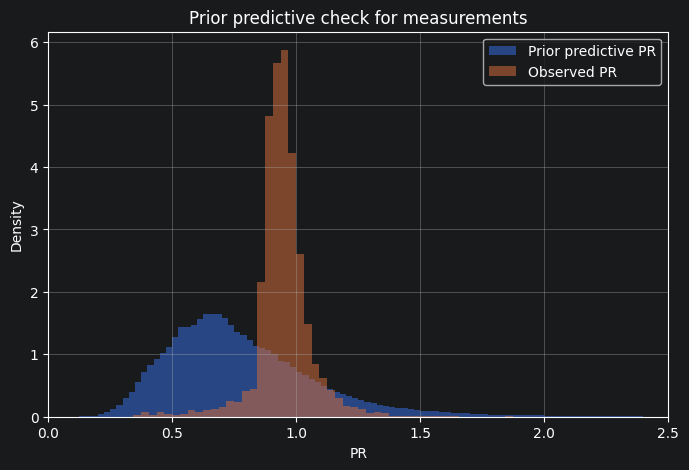

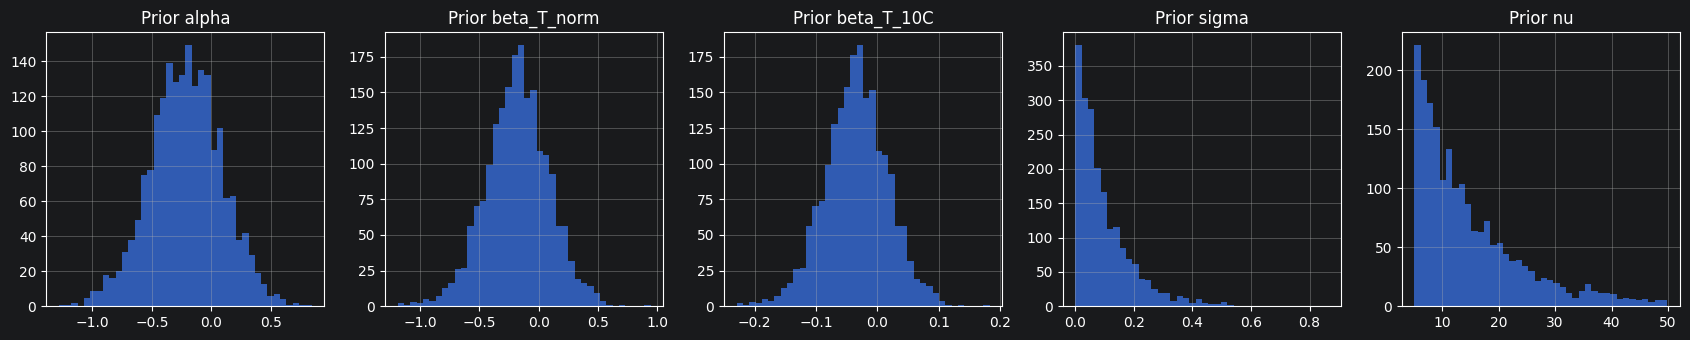

In [6]:
plt.figure()
plt.hist(PR_prior.flatten(), bins=100, range=(0, 2.5), density=True, alpha=0.55, label="Prior predictive PR")
plt.hist(df["PR"], bins=80,range=(0, 2.5), density=True, alpha=0.55, label="Observed PR")
plt.xlim(0, 2.5)
plt.xlabel("PR")
plt.ylabel("Density")
plt.title("Prior predictive check for measurements")
plt.xlim([0, 2.5])
plt.legend()
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(17, 3.5))
for ax, (name, samples) in zip(
    axes,
    [
        ("alpha", np.exp(alpha_prior)),
        ("beta_T_norm", beta_T_norm_prior),
        ("beta_T_10C", beta_T_10C_prior),
        ("sigma", sigma_prior),
        ("nu", nu_prior),
    ]
):
    ax.hist(samples, bins=40, alpha=0.8)
    ax.set_title(f"Prior {name}")
    ax.grid(True)
plt.tight_layout()
plt.show()

## 5. Fit Model 1

In [7]:

model = CmdStanModel(stan_file=str(STAN_MODEL_PATH), force_compile=True)
fit = model.sample(
    data=stan_data,
    chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    seed=RANDOM_SEED,
    adapt_delta=0.95,
    max_treedepth=12,
)

00:54:46 - cmdstanpy - INFO - compiling stan file /Users/jwiater/Documents/private/da_project/model_1_temperature_studentt.stan to exe file /Users/jwiater/Documents/private/da_project/model_1_temperature_studentt
00:54:51 - cmdstanpy - INFO - compiled model executable: /Users/jwiater/Documents/private/da_project/model_1_temperature_studentt
00:54:52 - cmdstanpy - INFO - CmdStan start processing
chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]


chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   5%|▌         | 100/2000 [00:00<00:02, 846.88it/s, (Warmup)]


chain 4:   5%|▌         | 100/2000 [00:00<00:07, 264.13it/s, (Warmup)]


chain 2:  10%|█         | 200/2000 [00:00<00:06, 264.04it/s, (Warmup)]

chain 3:  10%|█         | 200/2000 [00:00<00:08, 214.64it/s, (Warmup)]


chain 2:  20%|██        | 400/2000 [00:01<00:06, 256.83it/s, (Warmup)]


chain 1:  10%|█         | 200/2000 [00:02<00:18, 97.57


00:55:07 - cmdstanpy - INFO - CmdStan done processing.


## 6. Diagnostics

In [8]:
print(fit.diagnose())
summary = fit.summary()
display(summary.loc[["alpha", "beta_T_10C", "beta_T_norm", "sigma", "nu"]])

draws_pd = fit.draws_pd()
div_cols = [c for c in draws_pd.columns if c.endswith("__") and "divergent" in c]
n_div = int(draws_pd[div_cols[0]].sum()) if div_cols else 0
print("Number of divergences:", n_div)

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
alpha,0.122798,0.000074,0.003570,0.003606,0.116907,0.122774,0.128594,2340.59,2154.380,82.5838,1.00082
beta_T_10C,-0.056369,0.000022,0.001083,0.001105,-0.058117,-0.056382,-0.054551,2409.54,2033.470,85.0166,1.00074
beta_T_norm,-0.292554,0.000115,0.005623,0.005734,-0.301629,-0.292621,-0.283118,2409.54,2033.470,85.0166,1.00074
sigma,0.053052,0.000020,0.000864,0.000904,0.051699,0.053026,0.054490,1854.04,1960.290,65.4167,1.00213
nu,5.008160,0.000169,0.008272,0.005545,5.000490,5.005460,5.024890,1610.88,993.271,56.8373,1.00495


Number of divergences: 0


## 7. Posterior analysis

In [9]:
alpha = fit.stan_variable("alpha")
beta_T_10C = fit.stan_variable("beta_T_10C")
beta_T_norm = fit.stan_variable("beta_T_norm")
sigma = fit.stan_variable("sigma")
nu = fit.stan_variable("nu")
mu = fit.stan_variable("mu")

effect_10C_pct = 100 * (np.exp(beta_T_10C) - 1)
effect_1C_pct = 100 * (np.exp(beta_T_10C / 10.0) - 1)
effect_full_range_pct = 100 * (np.exp(beta_T_norm) - 1)

print(f"P(beta_T_10C < 0 | data) = {np.mean(beta_T_10C < 0):.4f}")

print("beta_T_10C percentiles:")
print(np.percentile(beta_T_10C, [5, 50, 95]))

print("beta_T_norm percentiles:")
print(np.percentile(beta_T_norm, [5, 50, 95]))

print("Effect per +10°C [%]:")
print(np.percentile(effect_10C_pct, [5, 50, 95]))

print("Effect per +1°C [%]:")
print(np.percentile(effect_1C_pct, [5, 50, 95]))

print("Effect over full temperature range [%]:")
print(np.percentile(effect_full_range_pct, [5, 50, 95]))

print("sigma percentiles:")
print(np.percentile(sigma, [5, 50, 95]))

print("nu percentiles:")
print(np.percentile(nu, [5, 50, 95]))

P(beta_T_10C < 0 | data) = 1.0000
beta_T_10C percentiles:
[-0.05811735 -0.05638171 -0.05455071]
beta_T_norm percentiles:
[-0.30162906 -0.29262109 -0.28311817]
Effect per +10°C [%]:
[-5.64607869 -5.48217203 -5.30895066]
Effect per +1°C [%]:
[-0.57948799 -0.56223067 -0.54402187]
Effect over full temperature range [%]:
[-26.03876371 -25.36951305 -24.65692499]
sigma percentiles:
[0.05169935 0.05302598 0.05449003]
nu percentiles:
[5.00049009 5.0054623  5.02488517]


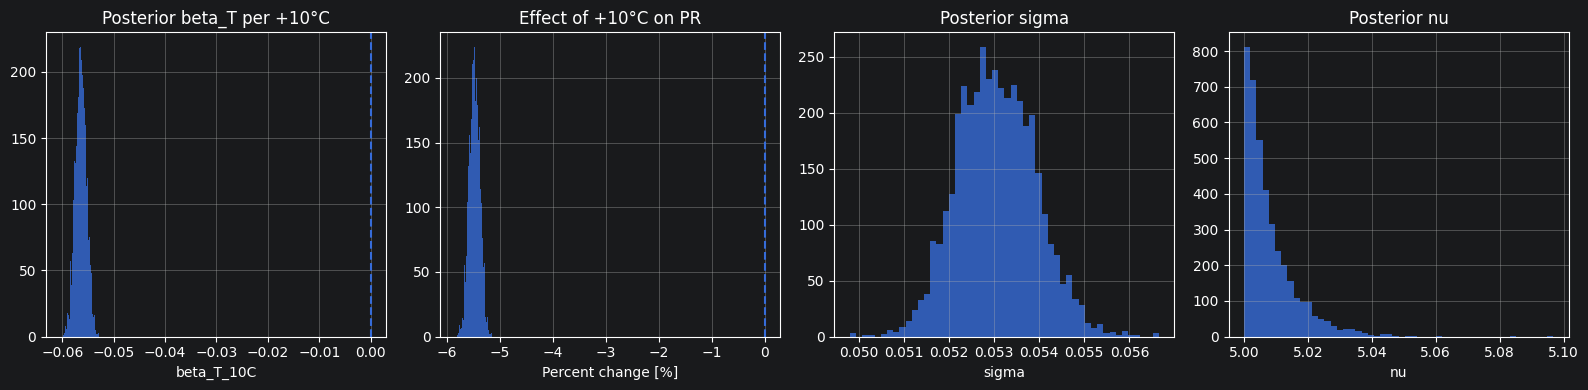

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
plots = [
    ("Posterior beta_T per +10°C", beta_T_10C, "beta_T_10C", True),
    ("Effect of +10°C on PR", effect_10C_pct, "Percent change [%]", True),
    ("Posterior sigma", sigma, "sigma", False),
    ("Posterior nu", nu, "nu", False),
]
for ax, (title, samples, xlabel, zero) in zip(axes, plots):
    ax.hist(samples, bins=50, alpha=0.8)
    if zero:
        ax.axvline(0, linestyle="--")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(True)
plt.tight_layout()
plt.show()

## 8. Posterior predictive check

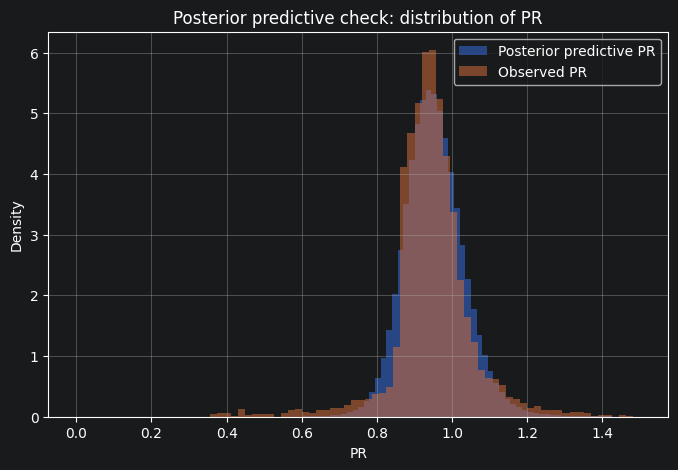

In [11]:
PR_pred = fit.stan_variable("PR_pred")
y_pred = fit.stan_variable("y_pred")

plt.figure(figsize=(8, 5))

plt.hist(
    PR_pred.flatten(),
    bins=100,
    range=(0, 1.5),
    density=True,
    alpha=0.55,
    label="Posterior predictive PR"
)

plt.hist(
    df["PR"],
    bins=80,
    range=(0, 1.5),
    density=True,
    alpha=0.55,
    label="Observed PR"
)

plt.xlabel("PR")
plt.ylabel("Density")
plt.title("Posterior predictive check: distribution of PR")
plt.legend()
plt.grid(True)
plt.show()

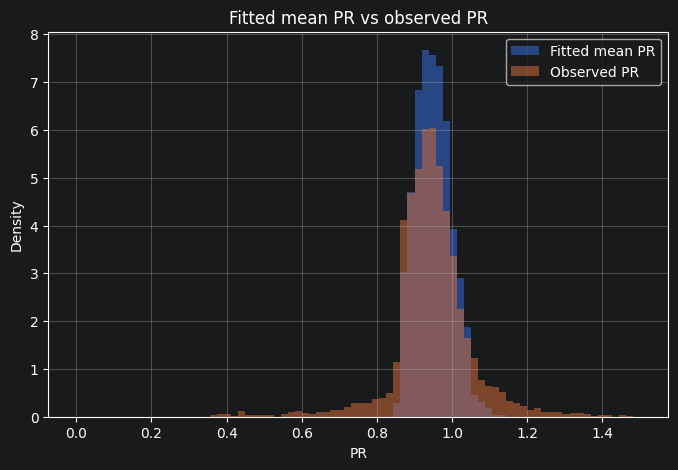

In [12]:
mu = fit.stan_variable("mu")
PR_mu = np.exp(mu)

PR_mu_mean = PR_mu.mean(axis=0)

plt.figure(figsize=(8, 5))

plt.hist(
    PR_mu_mean,
    bins=80,
    range=(0, 1.5),
    density=True,
    alpha=0.55,
    label="Fitted mean PR"
)

plt.hist(
    df["PR"],
    bins=80,
    range=(0, 1.5),
    density=True,
    alpha=0.55,
    label="Observed PR"
)

plt.xlabel("PR")
plt.ylabel("Density")
plt.title("Fitted mean PR vs observed PR")
plt.legend()
plt.grid(True)
plt.show()

## 9. Residual diagnostics — motivation for Model 2

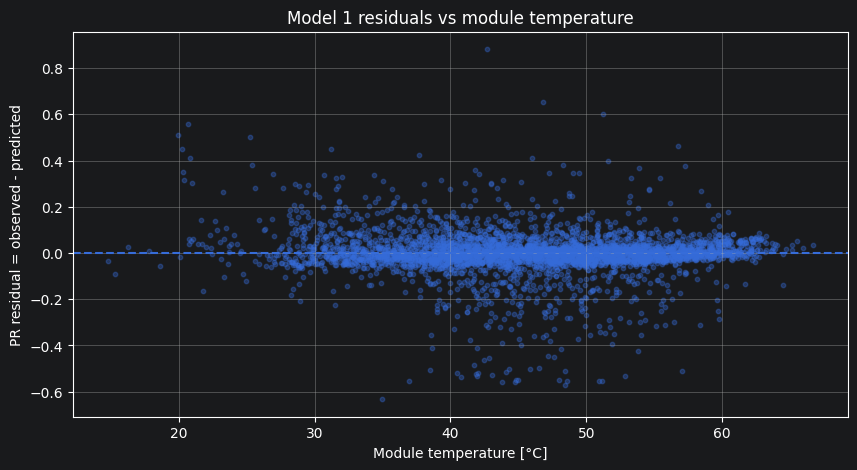

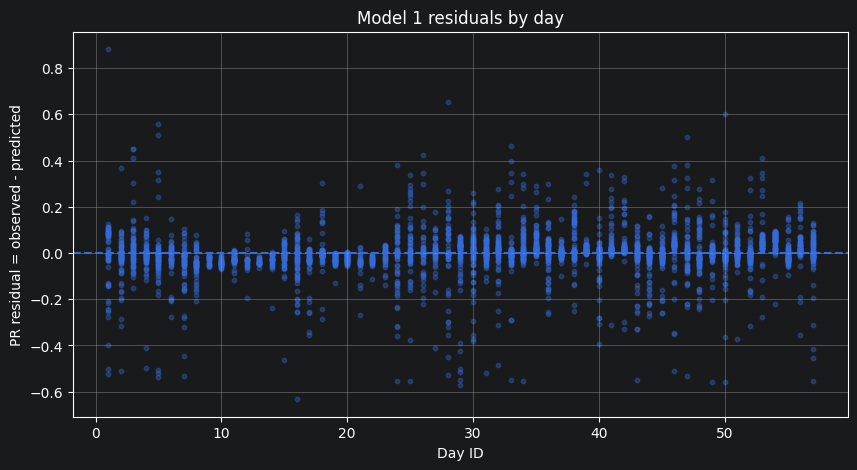

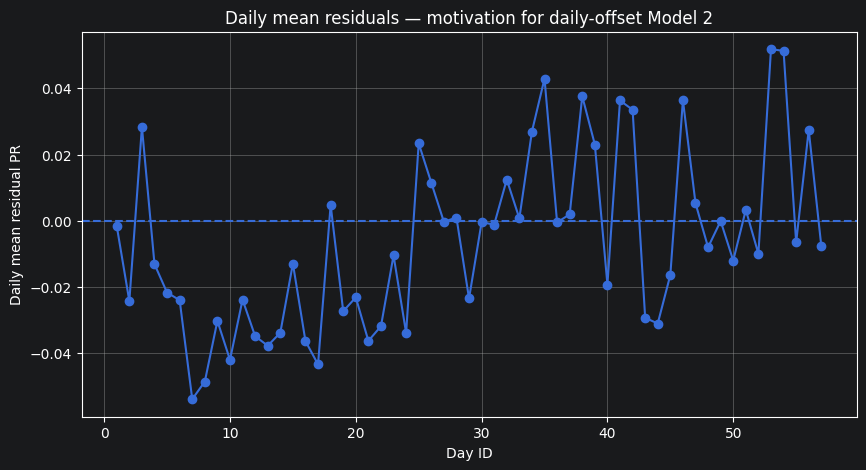

In [13]:
PR_mu_mean = np.exp(mu).mean(axis=0)

df_check = df.copy()
df_check["PR_pred_mean"] = PR_mu_mean
df_check["residual_PR"] = df_check["PR"] - df_check["PR_pred_mean"]

plt.figure(figsize=(10, 5))
plt.scatter(df_check["T_module_C"], df_check["residual_PR"], s=10, alpha=0.35)
plt.axhline(0, linestyle="--")
plt.xlabel("Module temperature [°C]")
plt.ylabel("PR residual = observed - predicted")
plt.title("Model 1 residuals vs module temperature")
plt.show()

if "day_id" in df_check.columns:
    plt.figure(figsize=(10, 5))
    plt.scatter(df_check["day_id"], df_check["residual_PR"], s=10, alpha=0.35)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Day ID")
    plt.ylabel("PR residual = observed - predicted")
    plt.title("Model 1 residuals by day")
    plt.show()

    daily_res = df_check.groupby("day_id").agg(daily_mean_residual=("residual_PR", "mean")).reset_index()
    plt.figure(figsize=(10, 5))
    plt.plot(daily_res["day_id"], daily_res["daily_mean_residual"], "o-")
    plt.axhline(0, linestyle="--")
    plt.xlabel("Day ID")
    plt.ylabel("Daily mean residual PR")
    plt.title("Daily mean residuals — motivation for daily-offset Model 2")
    plt.show()
else:
    print("No day_id column found, skipping daily residual diagnostics.")

## 10. Save ArviZ object

In [14]:
idata1 = az.from_cmdstanpy(
    posterior=fit,
    posterior_predictive=["y_pred"],
    observed_data={"y": y},
    log_likelihood=["log_lik"],
)


with open("idata_model1_temperature_studentt.pkl", "wb") as f:
    pickle.dump(idata1, f)

print("Saved: idata_model1_temperature_studentt.pkl")

Saved: idata_model1_temperature_studentt.pkl


## Interpretation

Model 1 is a robust temperature-only baseline. Temperature is min-max normalized, so $x_T \in [0,1]$. In this scale, $\alpha$ is the expected $\log(PR)$ at the minimum observed module temperature and $\beta_T$ is the change in $\log(PR)$ between the minimum and maximum observed module temperature. The $+10^\circ C$ effect is included as a physical-scale summary. The Student-t likelihood makes the model less sensitive to remaining outliers. The model does not include wind or day-level effects.